Dataset Shape: (25000, 18)
   Employee_ID Department Education   Location  Gender  Age  Experience  \
0            1  Marketing       PhD     Mumbai    Male   31          19   
1            2      Sales  Bachelor  Hyderabad    Male   59          28   
2            3    Finance       PhD  Hyderabad    Male   42          24   
3            4      Sales    Master    Chennai  Female   45          17   
4            5      Sales    Master     Mumbai  Female   55          21   

   Performance_Rating  Attendance        Salary         Bonus  \
0                   5          87  57956.985646   9181.058944   
1                   4          84  74393.218064  13635.982014   
2                   2          84  60068.146984  16021.692999   
3                   1          71  59337.602904  11848.950342   
4                   3          90  85781.095751   4254.628550   

   Projects_Handled  Training_Hours  Job_Satisfaction  Overtime_Hours  \
0                 3              39                 5     

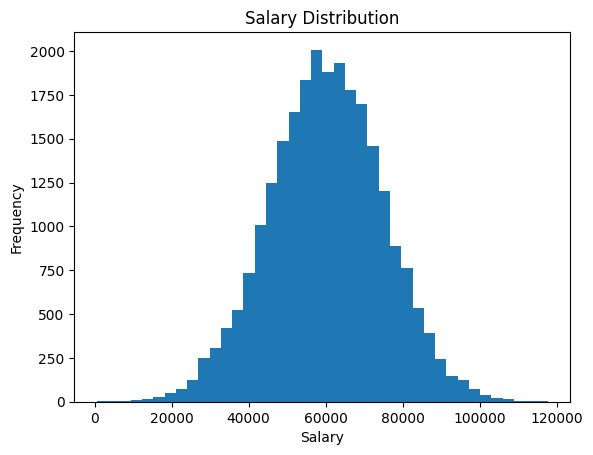

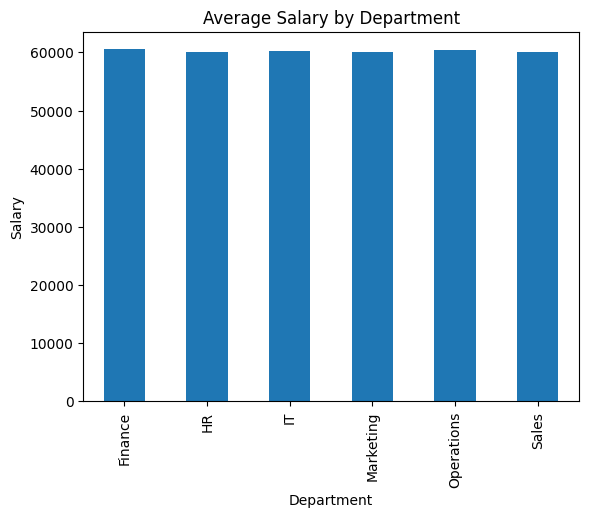

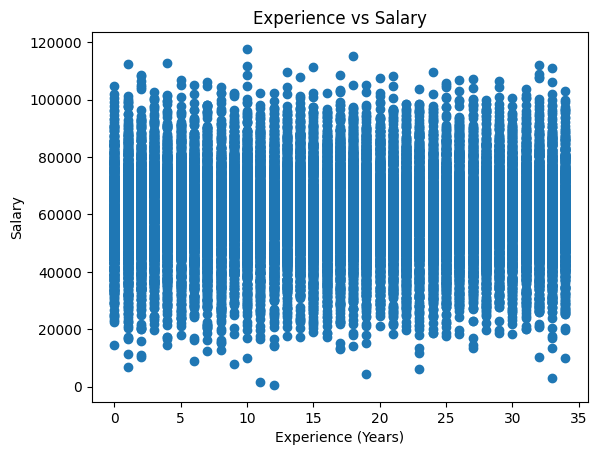

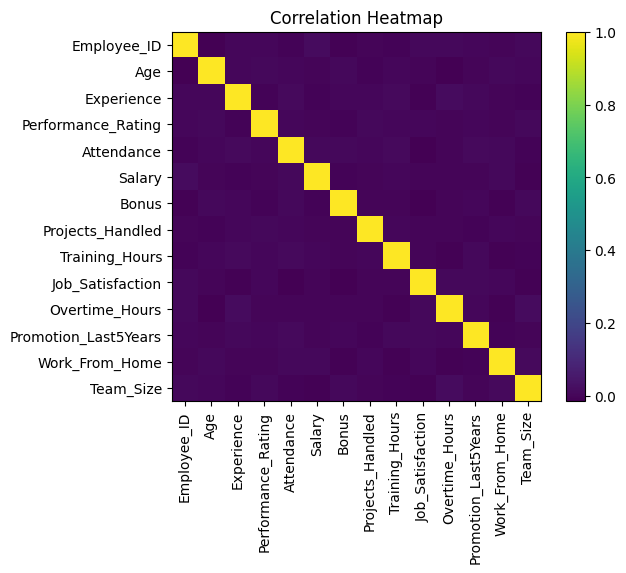

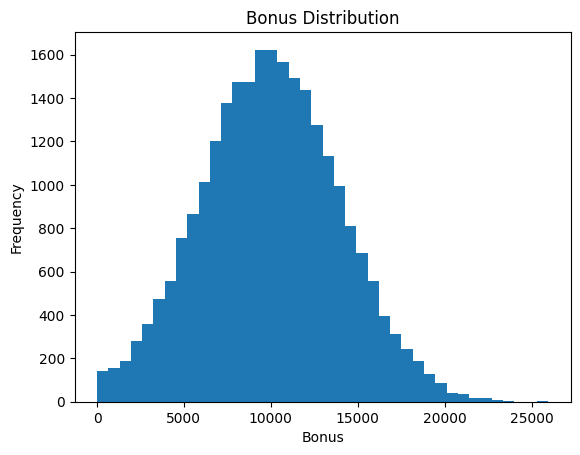

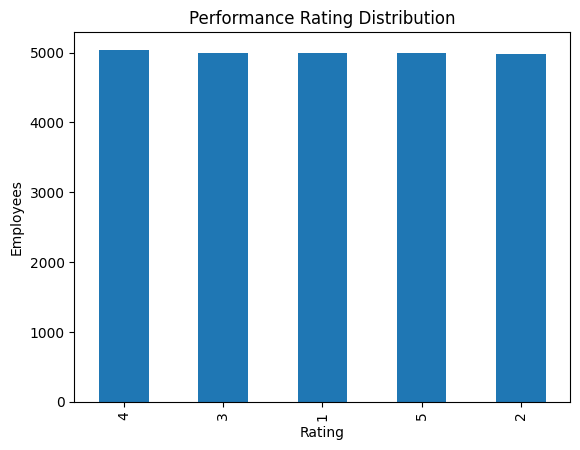

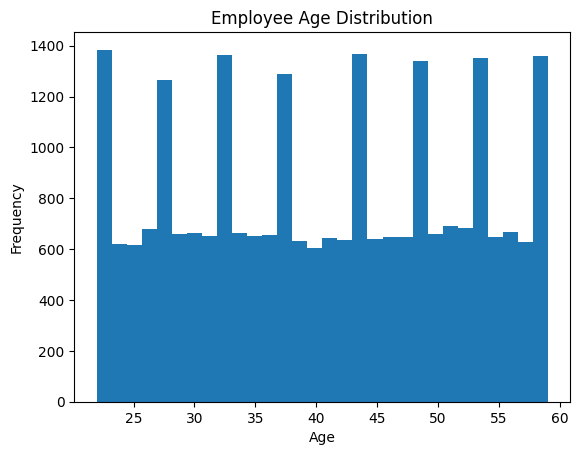

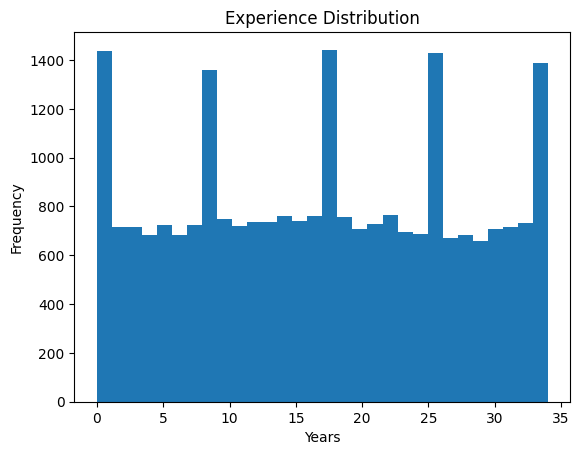

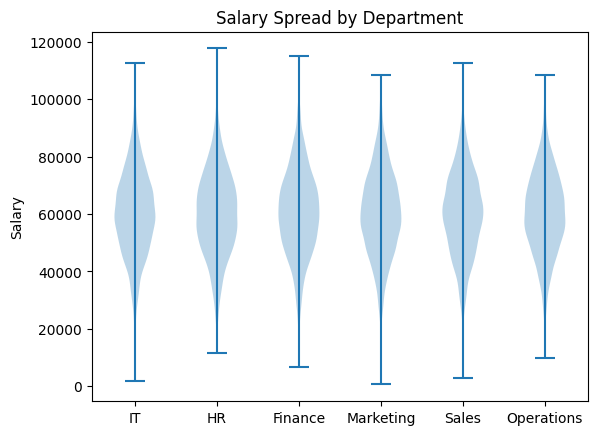

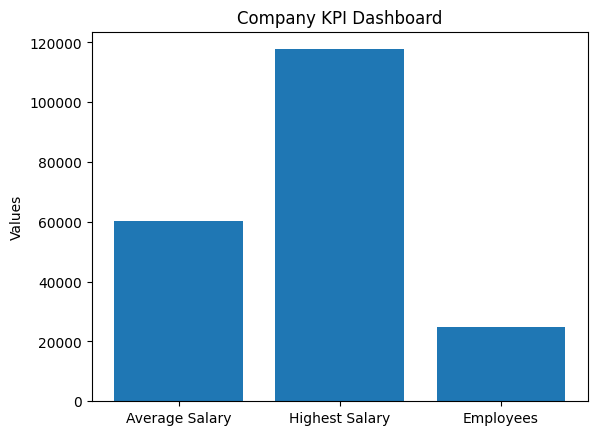


Employee Salary Analytics Completed Successfully


In [1]:
# EMPLOYEE SALARY ANALYTICS PROJECT
# Tech Stack: NumPy, Pandas, Matplotlib
# Dataset: 25,000 Employees (Synthetic Dataset)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. DATASET GENERATION

n = 25000

departments = ['IT','HR','Finance','Marketing','Sales','Operations']
education = ['Bachelor','Master','PhD']
locations = ['Chennai','Bangalore','Hyderabad','Pune','Mumbai']
gender = ['Male','Female']

data = {
    "Employee_ID": np.arange(1, n+1),
    "Department": np.random.choice(departments, n),
    "Education": np.random.choice(education, n),
    "Location": np.random.choice(locations, n),
    "Gender": np.random.choice(gender, n),
    "Age": np.random.randint(22, 60, n),
    "Experience": np.random.randint(0, 35, n),
    "Performance_Rating": np.random.randint(1, 6, n),
    "Attendance": np.random.randint(70, 100, n),
    "Salary": np.random.normal(60000,15000,n),
    "Bonus": np.random.normal(10000,4000,n),
    "Projects_Handled": np.random.randint(1, 15, n),
    "Training_Hours": np.random.randint(10, 200, n),
    "Job_Satisfaction": np.random.randint(1, 10, n),
    "Overtime_Hours": np.random.randint(0, 40, n),
    "Promotion_Last5Years": np.random.randint(0,2,n),
    "Work_From_Home": np.random.randint(0,2,n),
    "Team_Size": np.random.randint(2,20,n)
}

df = pd.DataFrame(data)

# 2. DATA CLEANING

df["Salary"] = df["Salary"].abs()
df["Bonus"] = df["Bonus"].abs()

df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)
print(df.head())

# 3. STATISTICAL ANALYSIS USING NUMPY

mean_salary = np.mean(df["Salary"])
median_bonus = np.median(df["Bonus"])
std_salary = np.std(df["Salary"])

correlation = np.corrcoef(df["Experience"], df["Salary"])[0,1]

print("\nSTATISTICAL ANALYSIS")
print("Mean Salary:", mean_salary)
print("Median Bonus:", median_bonus)
print("Salary Std Dev:", std_salary)
print("Correlation Experience vs Salary:", correlation)

# 4. OUTLIER DETECTION USING Z-SCORE

z_scores = (df["Salary"] - df["Salary"].mean()) / df["Salary"].std()
outliers = df[np.abs(z_scores) > 3]

print("\nNumber of Salary Outliers:", len(outliers))

# 5. KPI DASHBOARD VALUES

avg_salary = df["Salary"].mean()
max_salary = df["Salary"].max()
employee_count = df.shape[0]

print("\nKPI METRICS")
print("Average Salary:", avg_salary)
print("Highest Salary:", max_salary)
print("Total Employees:", employee_count)

# 6. VISUALISATION 1 – SALARY DISTRIBUTION HISTOGRAM
plt.figure()
plt.hist(df["Salary"], bins=40)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

# 7. VISUALISATION 2 – DEPARTMENT SALARY BAR CHART


dept_salary = df.groupby("Department")["Salary"].mean()

plt.figure()
dept_salary.plot(kind='bar')
plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.show()


# 8. VISUALISATION 3 – EXPERIENCE VS SALARY SCATTER


plt.figure()
plt.scatter(df["Experience"], df["Salary"])
plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.show()

# 9. VISUALISATION 4 – CORRELATION HEATMAP
#

numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr()

plt.figure()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.show()

# ----------------------------------------------------------
# 10. VISUALISATION 5 – BONUS DISTRIBUTION
# ----------------------------------------------------------

plt.figure()
plt.hist(df["Bonus"], bins=40)
plt.title("Bonus Distribution")
plt.xlabel("Bonus")
plt.ylabel("Frequency")
plt.show()

# ----------------------------------------------------------
# 11. VISUALISATION 6 – PERFORMANCE RATING COUNT
# ----------------------------------------------------------

rating_counts = df["Performance_Rating"].value_counts()

plt.figure()
rating_counts.plot(kind='bar')
plt.title("Performance Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Employees")
plt.show()

# ----------------------------------------------------------
# 12. VISUALISATION 7 – AGE DISTRIBUTION
# ----------------------------------------------------------

plt.figure()
plt.hist(df["Age"], bins=30)
plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# ----------------------------------------------------------
# 13. VISUALISATION 8 – EXPERIENCE DISTRIBUTION
# ----------------------------------------------------------

plt.figure()
plt.hist(df["Experience"], bins=30)
plt.title("Experience Distribution")
plt.xlabel("Years")
plt.ylabel("Frequency")
plt.show()

# ----------------------------------------------------------
# 14. VISUALISATION 9 – VIOLIN STYLE (SALARY BY DEPARTMENT)
# ----------------------------------------------------------

salary_data = [df[df["Department"]==d]["Salary"] for d in departments]

plt.figure()
plt.violinplot(salary_data)
plt.xticks(range(1,len(departments)+1), departments)
plt.title("Salary Spread by Department")
plt.ylabel("Salary")
plt.show()

# ----------------------------------------------------------
# 15. VISUALISATION 10 – KPI DASHBOARD STYLE
# ----------------------------------------------------------

labels = ['Average Salary','Highest Salary','Employees']
values = [avg_salary,max_salary,employee_count]

plt.figure()
plt.bar(labels,values)
plt.title("Company KPI Dashboard")
plt.ylabel("Values")
plt.show()

# ----------------------------------------------------------
# PROJECT COMPLETED
# ----------------------------------------------------------

print("\nEmployee Salary Analytics Completed Successfully")